In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thorgodofthunder/tvradionewspaperadvertising")

print("Path to dataset files:", path)

100%|██████████| 1.83k/1.83k [00:00<00:00, 1.15MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/thorgodofthunder/tvradionewspaperadvertising/versions/1


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
print("All modules import successfully")

All modules import successfully


In [4]:
# 3 view dataset
path

'/root/.cache/kagglehub/datasets/thorgodofthunder/tvradionewspaperadvertising/versions/1'

In [7]:
filename = os.listdir(path)[0]

In [8]:
filepath=path+'/'+filename
filepath

'/root/.cache/kagglehub/datasets/thorgodofthunder/tvradionewspaperadvertising/versions/1/Advertising.csv'

In [16]:
df = pd.read_csv(filepath)

In [17]:
df.sample()

,TV,Radio,Newspaper,Sales
79,116.0,7.7,23.1,11.0


In [18]:
# step 4 :- EDA Performance
rows, columns = df.shape
print(f'''This Dataset Contains
      rows : {rows},
      columns : {columns}
''')

This Dataset Contains
      rows : 200,
      columns : 4



In [19]:
df.tail()

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,18.4


In [20]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [22]:
# Handle Null Data
# Remove, Replace, Fill
df.isna().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [24]:
df.describe().round(2)

,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,15.13
std,85.85,14.85,21.78,5.28
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,11.00
50%,149.75,22.90,25.75,16.00
75%,218.82,36.52,45.10,19.05
max,296.40,49.60,114.00,27.00


In [25]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


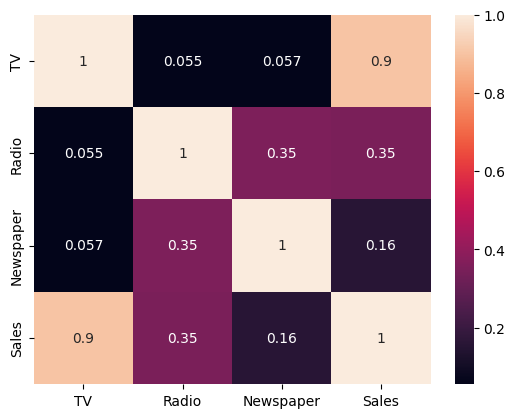

In [28]:
sns.heatmap(df.corr(),annot=True)
plt.show()

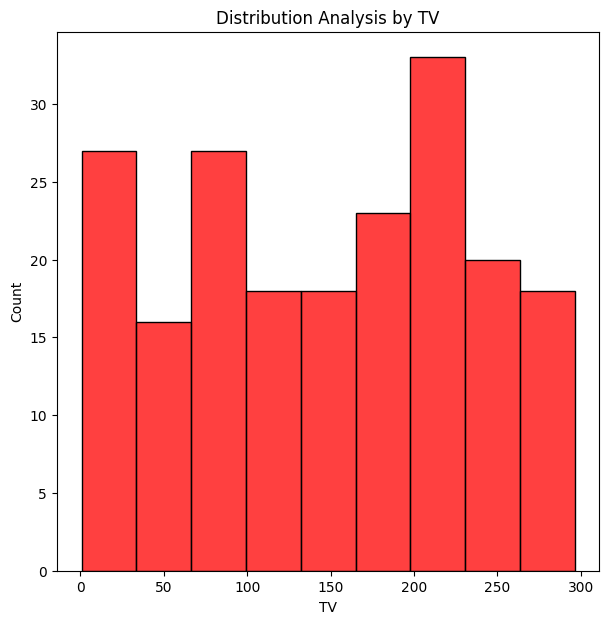

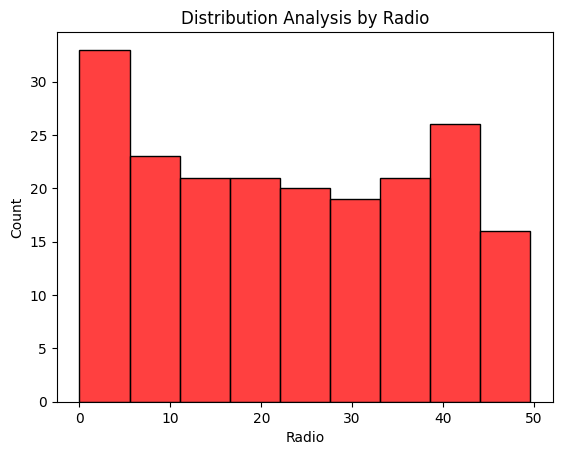

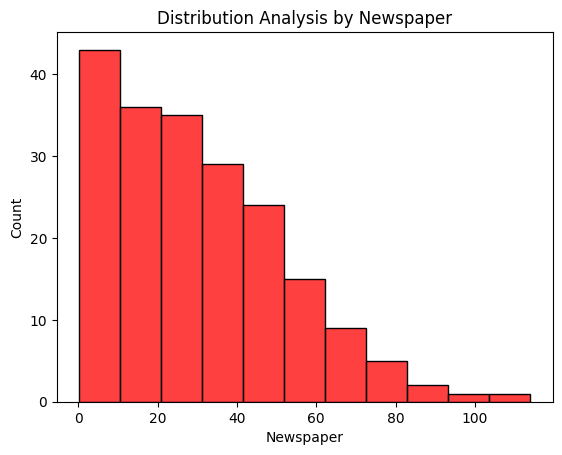

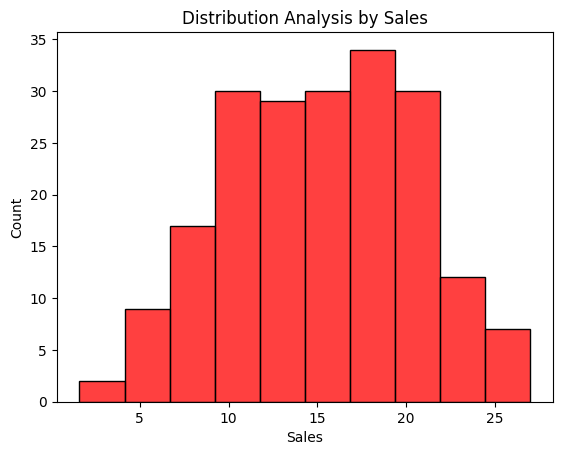

In [30]:
plt.figure(figsize=(7,7))
for i in df:
  plt.title(f'Distribution Analysis by {i}')
  sns.histplot(data=df,x=i,color='r')
  plt.show()

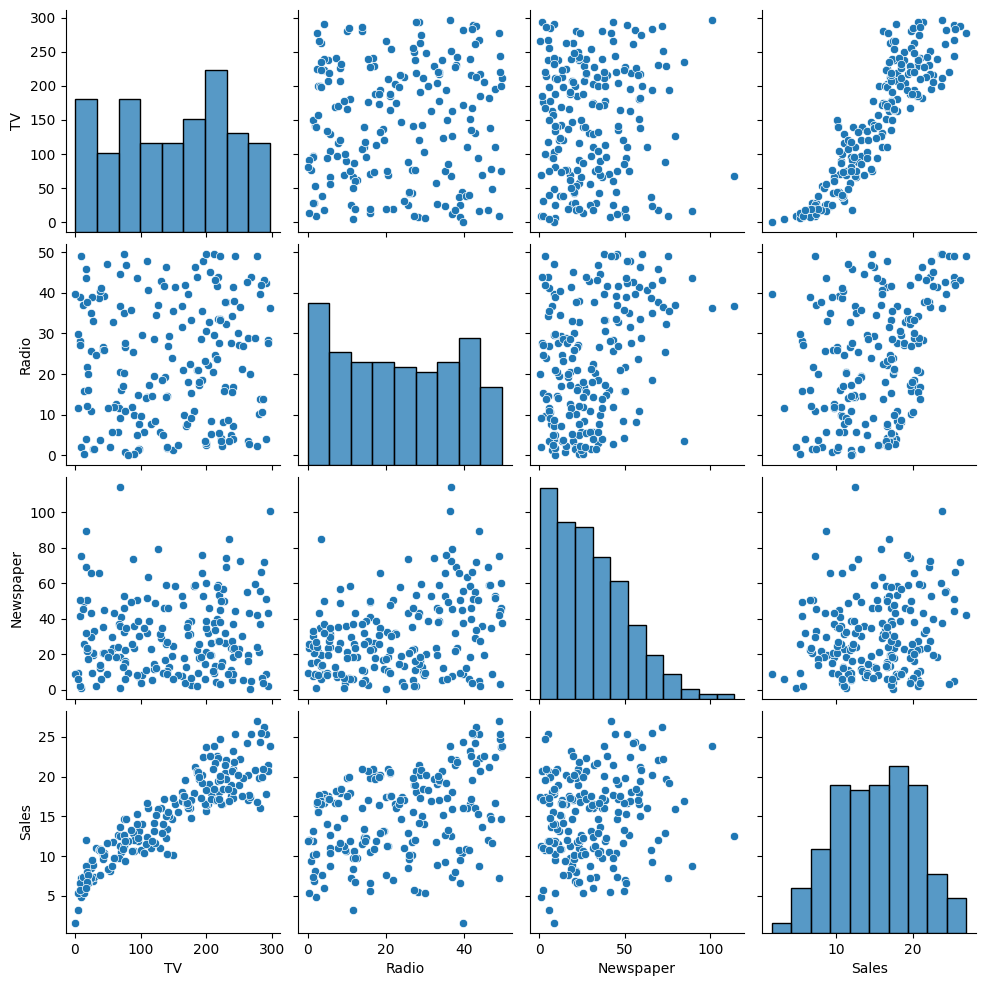

In [31]:
sns.pairplot(data = df)
plt.show()

In [32]:
# features = tv, radio, newspaper
# target = sales


In [37]:
# Step 5 : Divide data into features and targets

X = df.iloc[:,:3]
y = df.iloc[:,-1]


In [38]:
print(X.shape)
print(y.shape)

(200, 3)
(200,)


In [40]:
# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [42]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


In [ ]:
# Step 6: Model Building

In [ ]:
# sales = m1*tv + m2*radio + m3*newspaper + c

In [45]:
model = LinearRegression()
# Train part, test part
model.fit(X_train,y_train)                       # Training step (This step will understand the underlying pattern and find the best fit line)


LinearRegression()

In [46]:
# Hyper Parameter Tuning : Fine Tune

In [48]:
# Step 7: sales Prediction using model

print("Model Prediction")
y_pred = model.predict(X_test)
y_pred

Model Prediction


array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

In [ ]:
# Step 8 : Model Evaluation

In [59]:
score = model.score(X_test,y_test)
score= round(score,4)*100
print(score)

# Model has achieved 90.6% of accuracy represent good model

# Error
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

print(f"MAE : {mae}")
print(f"MSE : {mse}")
print(f"RMSE : {rmse}")

90.59
MAE : 1.2748262109549338
MSE : 2.9077569102710896
RMSE : 1.7052146229349223


In [58]:
mae = mean_absolute_error(y_test,y_pred)
mae

1.2748262109549338

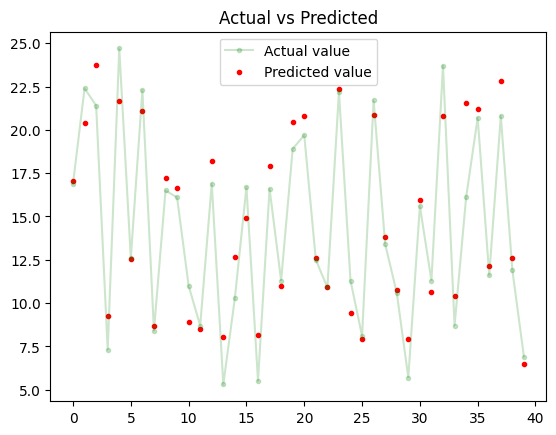

In [63]:
plt.title("Actual vs Predicted")
plt.plot(range(0,len(y_test)), y_test,label= 'Actual value', color='g',marker='.',alpha=0.2)
plt.scatter(range(0,len(y_pred)), y_pred, label = 'Predicted value',color='r',marker='.')
plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

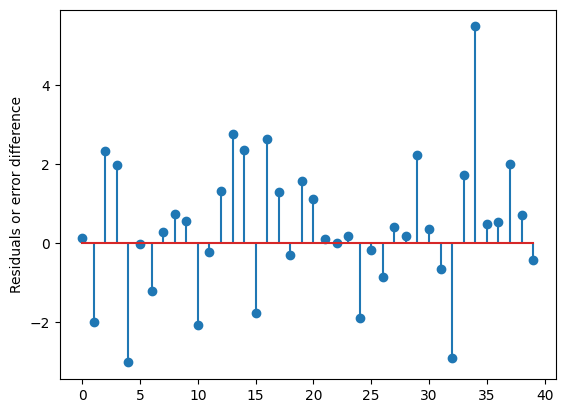

In [66]:
plt.stem(y_pred-y_test)
plt.ylabel("Residuals or error difference")
plt.show

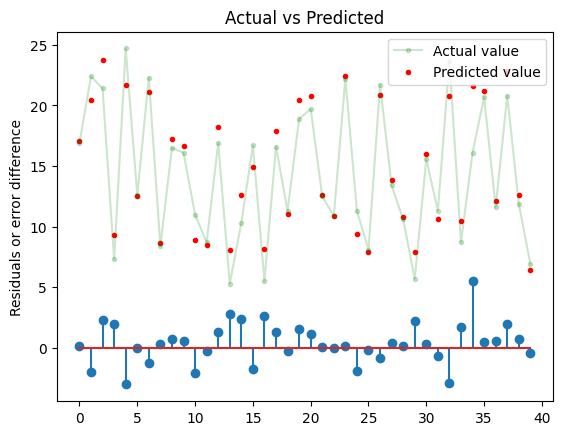

In [68]:
plt.title("Actual vs Predicted")
plt.plot(range(0,len(y_test)), y_test,label= 'Actual value', color='g',marker='.',alpha=0.2)
plt.scatter(range(0,len(y_pred)), y_pred, label = 'Predicted value',color='r',marker='.')
plt.stem(y_pred-y_test)
plt.ylabel("Residuals or error difference")
plt.legend()
plt.show()

In [ ]:
# Step 9 : Sales prediction based on user input

In [71]:
tv_budget = float(input("Enter Tv Budget: "))
radio_budget = float(input("Enter radio Budget: "))
newspaper_budget = float(input("Enter newspaper Budget: "))

user_data=[[tv_budget,radio_budget,newspaper_budget]]
Predicted_Sale = model.predict(user_data)[0]
print(f"Estimated predicted sale: {round(Predicted_Sale,2)}")

Enter Tv Budget: 100
Enter radio Budget: 40
Enter newspaper Budget: 20
Estimated predicted sale: 14.29


In [ ]:
#step 10: Final model save